# Imports

In [15]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

# Data
https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images

In [13]:
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

normal_dir = '/kaggle/input/labeled-chest-xray-images/chest_xray/train/NORMAL'
pneumonia_dir = '/kaggle/input/labeled-chest-xray-images/chest_xray/train/PNEUMONIA'

IMG_SIZE = (150, 150)

def load_images_from_directory(directory, label):
    images = []
    labels = []
    for filename in os.listdir(directory):
        img_path = os.path.join(directory, filename)
        image = cv2.imread(img_path)
        image = cv2.resize(image, IMG_SIZE)
        images.append(image)
        labels.append(label)
    return images, labels

normal_images, normal_labels = load_images_from_directory(normal_dir, 0)
pneumonia_images, pneumonia_labels = load_images_from_directory(pneumonia_dir, 1)

X_normal = np.array(normal_images)
y_normal = np.array(normal_labels)
X_pneumonia = np.array(pneumonia_images)
y_pneumonia = np.array(pneumonia_labels)

X_normal = X_normal / 255.0
X_pneumonia = X_pneumonia / 255.0

In [15]:
from sklearn.utils import resample

n_normal_samples = min(len(X_normal), len(X_pneumonia))
X_normal_downsampled, y_normal_downsampled = resample(
    X_normal, y_normal, 
    replace=False, 
    n_samples=n_normal_samples, 
    random_state=42
)

X_combined = np.vstack((X_normal_downsampled, X_pneumonia))
y_combined = np.hstack((y_normal_downsampled, y_pneumonia))

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

batch_size = 32
epochs = 20

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=(X_val, y_val),
    epochs=epochs
)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 20/130 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.6086 - loss: 0.8059

2024-06-17 23:50:45.846325: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 29: 6.64925, expected 5.76108
2024-06-17 23:50:45.846397: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 37: 7.74153, expected 6.85335
2024-06-17 23:50:45.846407: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 53: 7.83466, expected 6.94648
2024-06-17 23:50:45.846415: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 56: 7.83186, expected 6.94369
2024-06-17 23:50:45.846423: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57: 7.68861, expected 6.80044
2024-06-17 23:50:45.846431: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 81: 7.7395, expected 6.85132
2024-06-17 23:50:45.846457: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 144: 7.82463, expected 6.93645
2024-06-17 23:50:45.846465: E external/local_xla

128/130 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6981 - loss: 1.5270

2024-06-17 23:51:05.957957: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21904: 7.76293, expected 6.8537
2024-06-17 23:51:05.958024: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21905: 6.41279, expected 5.50355
2024-06-17 23:51:05.958038: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21906: 6.75325, expected 5.84401
2024-06-17 23:51:05.958048: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21907: 7.65731, expected 6.74807
2024-06-17 23:51:05.958062: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21908: 7.75257, expected 6.84334
2024-06-17 23:51:05.958079: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21911: 7.70149, expected 6.79226
2024-06-17 23:51:05.958091: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 21912: 6.49042, expected 5.58118
2024-06-17 23:51:05.958102: 

130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.6989 - loss: 1.5157 - val_accuracy: 0.7230 - val_loss: 1.7382
Epoch 2/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6562 - loss: 0.5600

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6562 - loss: 0.5600 - val_accuracy: 0.7230 - val_loss: 1.7711
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.7470 - loss: 0.9652 - val_accuracy: 0.8415 - val_loss: 0.3601
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9062 - loss: 0.3569 - val_accuracy: 0.8644 - val_loss: 0.3567
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.8207 - loss: 0.4209 - val_accuracy: 0.8863 - val_loss: 0.3215
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8750 - loss: 0.3026 - val_accuracy: 0.8902 - val_loss: 0.3219
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.8835 - loss: 0.2949 - val_accuracy: 0.8797 - val_loss: 0.2761
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.3375 - val_accuracy: 0.8883 - val_loss: 0.2625
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.8867 - loss: 0.2804 - val_accuracy: 0

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       290
           1       0.96      0.96      0.96       757

    accuracy                           0.95      1047
   macro avg       0.93      0.93      0.93      1047
weighted avg       0.95      0.95      0.95      1047



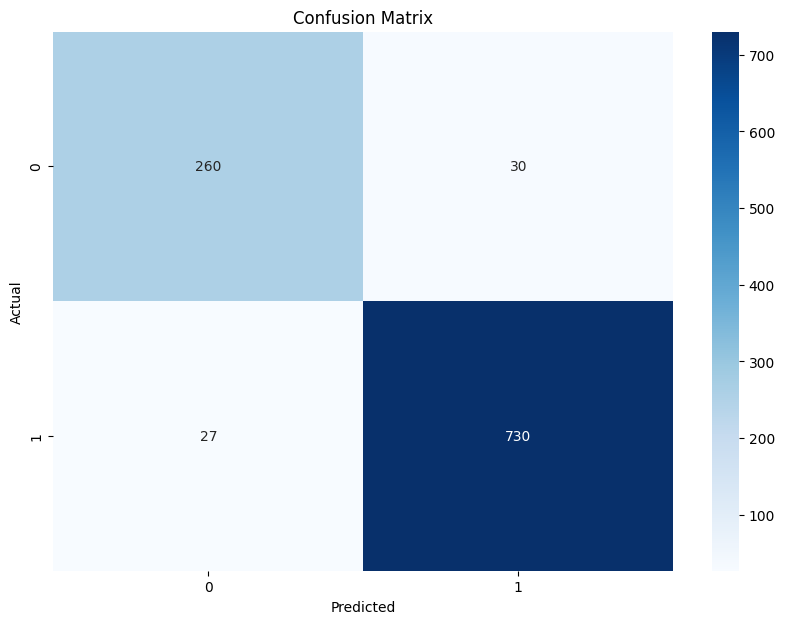

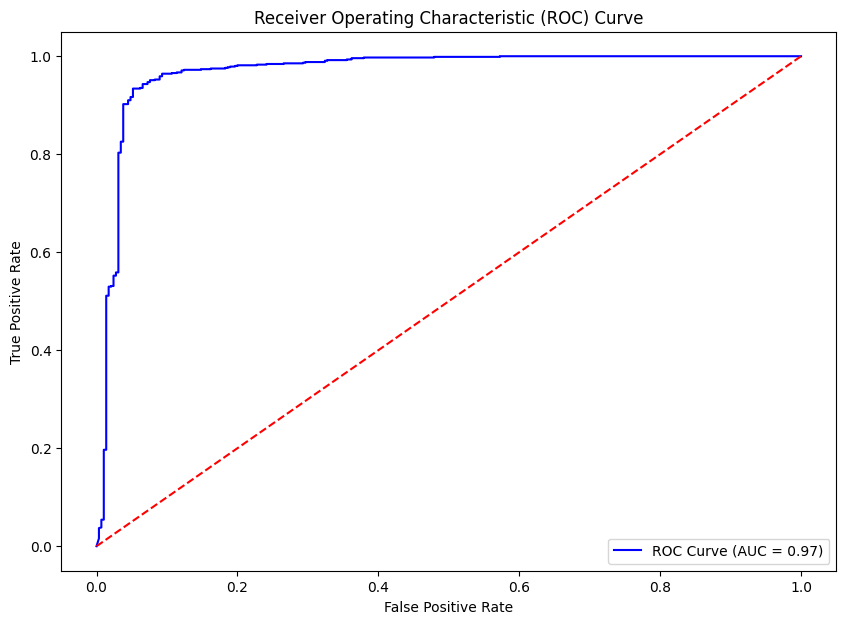

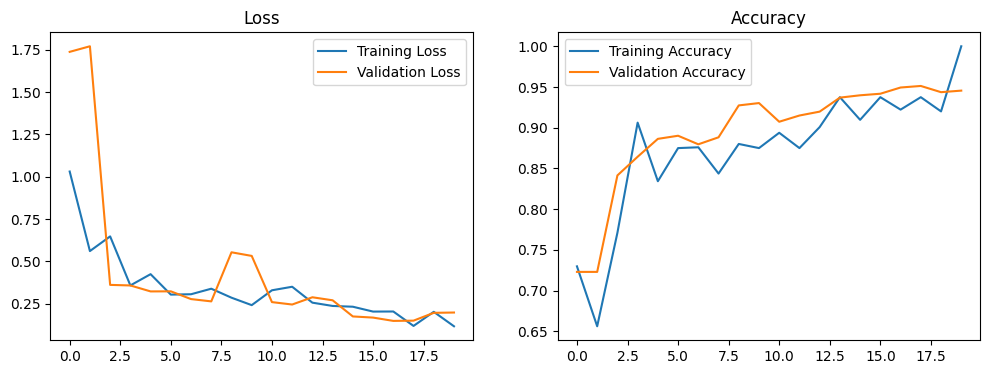

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

y_val_pred = model.predict(X_val).ravel()
y_val_pred_class = (y_val_pred > 0.5).astype(int)

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_val_pred_class))

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred_class)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()


In [19]:
model.save("/kaggle/working/model_95.h5")